# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: L.B.J.SUBERBERE
* Username: lbjsuberbere
* Student number: s6080081
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
import sympy as sp
from scipy.integrate import quad
import random

class integration:
    def __init__(self, func, a, b):
        self.func = func
        self.a = a
        self.b = b

        #function input handler (otherwise shows errors of not read the expression)
        self.x = sp.symbols('x')
        self.sympy_expr = sp.sympify(func)
        self.func = sp.lambdify(self.x, self.sympy_expr, 'numpy')
    
    # Trapezoidal rule
    def trapezium(self):
        return (self.b - self.a) * (self.func(self.a) + self.func(self.b)) / 2
    
    # Simpson's rule
    def simpson(self, n=1000):  
        h = (self.b - self.a) / n
        x = np.linspace(self.a, self.b, n + 1)
        y = self.func(x)
        return (h/3) * (y[0] + y[-1] + 2*np.sum(y[2:n:2]) + 4*np.sum(y[1:n:2]))
    
    # Monte Carlo integration
    def montecarlo(self, n=10000):
        total = 0
        for _ in range(n):
            x_rand = random.uniform(self.a, self.b)
            total += self.func(x_rand)
        return (self.b - self.a) * total / n
    
    # SymPy integration
    def sympy(self):
        result = sp.integrate(self.sympy_expr, (self.x, self.a, self.b))
        return result
    
    # SciPy integration
    def scipy(self):
        result, _ = quad(self.func, self.a, self.b)
        return result

        
#test
func = "1 + x + sin(2*x)"
a = 0.5
b = 3.0

area = integration(func, a, b)

print(f'For the function {func} on interval [{a}, {b}], the area values are :')
print("Trapezoidal Rule:", area.trapezium())
print("Simpson's Rule:", area.simpson())
print("Monte Carlo:", area.montecarlo())
print("SymPy Integral:", area.sympy())
print("SciPy Integral:", area.scipy())

For the function 1 + x + sin(2*x) on interval [0.5, 3.0], the area values are :
Trapezoidal Rule: 7.577569358261213
Simpson's Rule: 6.665066009608159
Monte Carlo: 6.6452538563124195
SymPy Integral: 6.66506600960889
SciPy Integral: 6.6650660096088865


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

Text(0.5, 1.0, 'Global HI Profile at (x=58, y=55)')

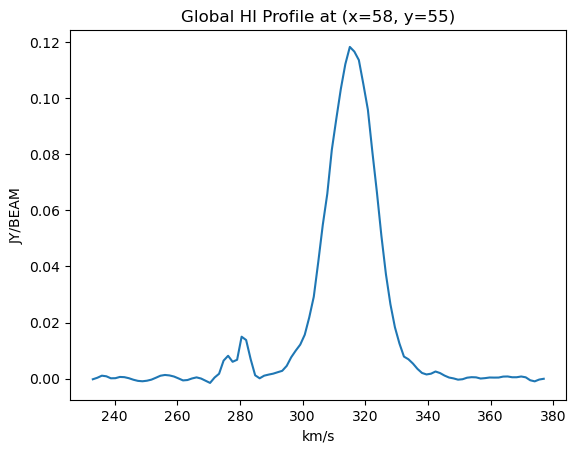

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

#Load fits file
hdul = fits.open("ngc6946.fits")
data = hdul[0].data
header = hdul[0].header

#slice
spectrum = data[:, 55, 58]

#Velocity axis
velocity = np.linspace(233, 377, len(spectrum))

#OO plot
fig, ax = plt.subplots()
ax.plot(velocity, spectrum)
ax.set_xlabel(header.get('CUNIT3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))
ax.set_title("Global HI Profile at (x=58, y=55)")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
import numpy as np

def f(x, amp, mu, sigma, zero):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + zero

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [8]:
# f(x) = amp * exp(-(x - mu)^2 / (2*sigma^2)) + zero
# A linear model has parameters only as multipliers.
# Here, mu and sigma are inside the exponential so not linear.

print("Mu and sigma are inside the exponential so the model is non linear")

Mu and sigma are inside the exponential so the model is non linear


In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
from scipy.optimize import curve_fit

#Initial estimates
amp_init = spectrum.max() - spectrum.min()
zero_init = spectrum.min()
mu_init = velocity[np.argmax(spectrum)]
sigma_init = (velocity[-1] - velocity[0]) / 8

p0 = [amp_init, mu_init, sigma_init, zero_init]
print("Initial estimates:", p0)

#Fit using curve_fit
bestfitparam, uncertainty = curve_fit(f, velocity, spectrum, p0=p0)

#Extract best-fit parameters and standard errors
amp_fit, mu_fit, sigma_fit, zero_fit = bestfitparam
perr = np.sqrt(np.diag(uncertainty)) 

print("Best-fit parameters:")
print(f"Amplitude = {amp_fit:.2f} +- {perr[0]:.2f}")
print(f"Center = {mu_fit:.2f} +- {perr[1]:.2f} km/s")
print(f"Sigma = {sigma_fit:.2f} +- {perr[2]:.2f} km/s")
print(f"Offset = {zero_fit:.2f} +- {perr[3]:.2f}")

Initial estimates: [np.float32(0.11970411), np.float64(315.08), np.float64(18.0), np.float32(-0.0014954247)]
Best-fit parameters:
Amplitude = 0.12 +- 0.00
Center = 315.72 +- 0.08 km/s
Sigma = 7.26 +- 0.08 km/s
Offset = 0.00 +- 0.00


* amp: Difference between max and min gives a reasonable guess for peak height.
* zero: The minimum of the spectrum approximates the baseline offset.
* mu: The velocity at maximum intensity approximates the Gaussian center.
* sigma: Rough estimate as ~1/8 of the full velocity range, assuming the line is not extremely broad.

In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

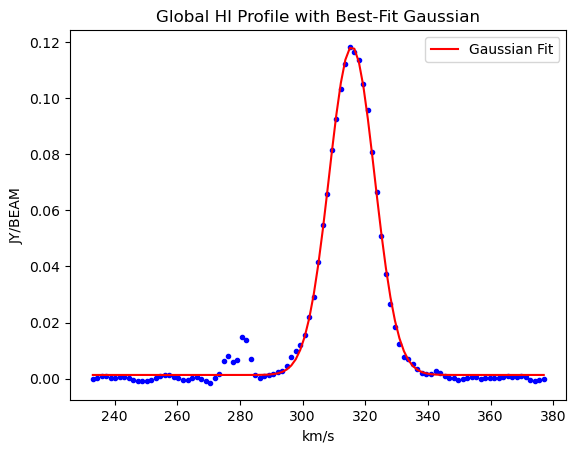

In [12]:
#OO plot
fig, ax = plt.subplots()

ax.plot(velocity, spectrum, 'b.') #Data
ax.plot(velocity, f(velocity, *bestfitparam), 'r-', label="Gaussian Fit")

ax.set_xlabel(header.get('CUNIT3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))
ax.set_title("Global HI Profile with Best-Fit Gaussian")
ax.legend()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

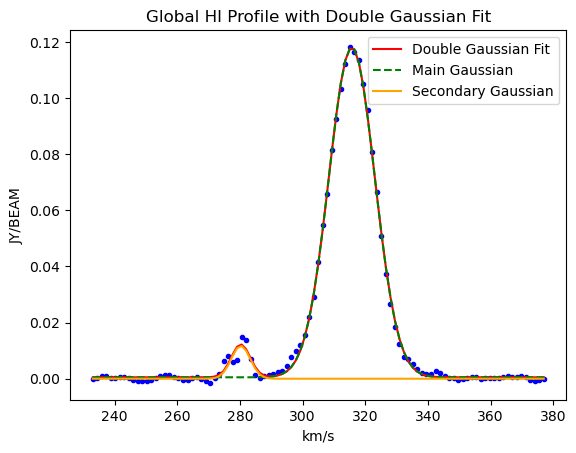

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Double Gaussian
def double_gaussian(x, a1, mu1, s1, zero, a2, mu2, s2):
    return a1*np.exp(-((x-mu1)**2)/(2*s1**2)) + zero + a2*np.exp(-((x-mu2)**2)/(2*s2**2))

# Initial guesses
p0 = [bestfitparam[0], bestfitparam[1], bestfitparam[2], bestfitparam[3], 0.3*bestfitparam[0], bestfitparam[1]-20, 0.8*bestfitparam[2]]

# Fit
bestfitparam2, _ = curve_fit(double_gaussian, velocity, spectrum, p0=p0)
a1, mu1, s1, zero, a2, mu2, s2 = bestfitparam2

# Plot
fig, ax = plt.subplots()
ax.plot(velocity, spectrum, 'b.')
ax.plot(velocity, double_gaussian(velocity, *bestfitparam2), 'r-', label='Double Gaussian Fit')
ax.plot(velocity, a1*np.exp(-((velocity-mu1)**2)/(2*s1**2)) + zero, 'g--', label='Main Gaussian')
ax.plot(velocity, a2*np.exp(-((velocity-mu2)**2)/(2*s2**2)), 'orange', label='Secondary Gaussian')
ax.set_xlabel(header.get('CUNIT3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))
ax.set_title("Global HI Profile with Double Gaussian Fit")
ax.legend()

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [16]:
import numpy as np
from scipy.signal import find_peaks

#Main peak
fwhmfactor = 2 * np.sqrt(2 * np.log(2))

FWHMmain = fwhmfactor * bestfitparam[2]
FWHMmainerr = fwhmfactor * perr[2]

print(f"Main peak FWHM = {FWHMmain:.2f} +- {FWHMmainerr:.2f} km/s")

#Secondary peak
#Find peaks
peaks, _ = find_peaks(spectrum)

#Sort peaks by height to pick the strongers
peak_heights = spectrum[peaks]
sorted_indices = np.argsort(peak_heights)

secondpeakidx = peaks[sorted_indices[-2]]
halfmax = spectrum[secondpeakidx] / 2

#Find left half max
leftidx = secondpeakidx
while leftidx > 0 and spectrum[leftidx] > halfmax:
    leftidx -= 1

#Find right half max
rightidx = secondpeakidx
while rightidx < len(spectrum) - 1 and spectrum[rightidx] > halfmax:
    rightidx += 1

#Convert to velocity width
FWHMsecondary = velocity[rightidx] - velocity[leftidx]

#Error estimate
FWHMsecondaryerr = FWHMsecondary * (perr[2] / bestfitparam[2])

print(f"Secondary peak FWHM = {FWHMsecondary:.2f} +- {FWHMsecondaryerr:.2f} km/s")

Main peak FWHM = 17.10 +- 0.19 km/s
Secondary peak FWHM = 4.32 +- 0.05 km/s


In [17]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

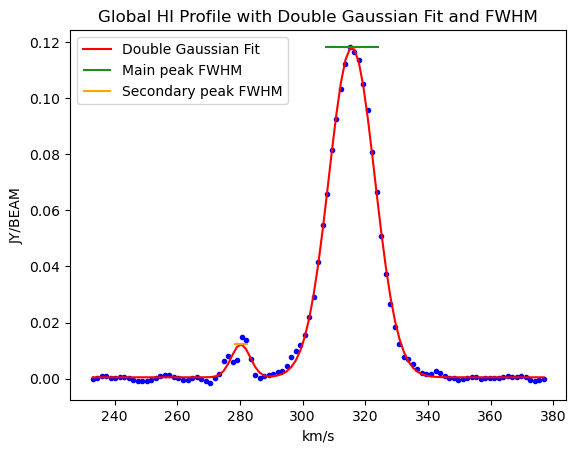

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Plot data points
ax.plot(velocity, spectrum, 'b.') #Data

# Plot double Gaussian fit
ax.plot(velocity, double_gaussian(velocity, *bestfitparam2), 'r-', label='Double Gaussian Fit')

#Main peak FWHM line
maincenter = mu1
mainleft = maincenter - FWHMmain / 2
mainright = maincenter + FWHMmain / 2
mainy = a1 * np.exp(-((maincenter - mu1)**2) / (2 * s1**2)) + zero  #height at center
ax.hlines(mainy, mainleft, mainright, colors='forestgreen', label='Main peak FWHM')

#Secondary peak FWHM line
secondcenter = mu2
secondleft = secondcenter - FWHMsecondary / 2
secondright = secondcenter + FWHMsecondary / 2
secondy = a2 * np.exp(-((secondcenter - mu2)**2) / (2 * s2**2)) + zero  #height at center
ax.hlines(secondy, secondleft, secondright, colors='orange', label='Secondary peak FWHM')

#labels
ax.set_xlabel(header.get('CUNIT3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))
ax.set_title("Global HI Profile with Double Gaussian Fit and FWHM")
ax.legend()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   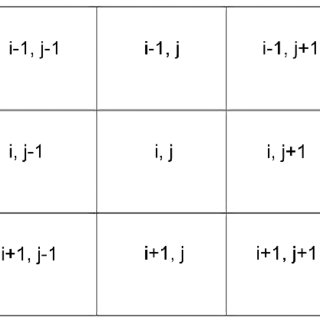    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

Text(0.5, 1.0, 'Smoothed (3x3 Mean)')

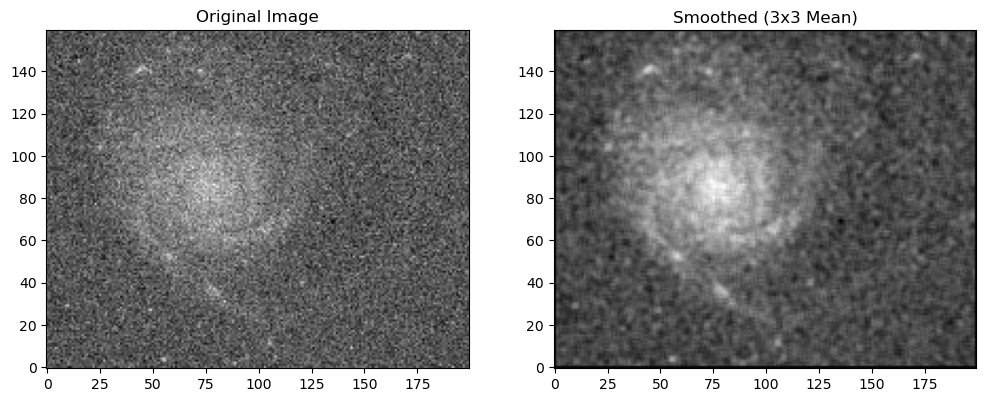

In [20]:
import numpy as np
from scipy import ndimage
from astropy.io import fits
import matplotlib.pyplot as plt

def smooth(M):
    ny, nx = M.shape
    
    # Create output array (copy)
    Mc = np.zeros_like(M, dtype=float)
    
    #Loop over interior pixels only
    for y in range(1, ny-1):
        for x in range(1, nx-1):
            Mc[y, x] = np.mean(M[y-1:y+2, x-1:x+2])
    
    #Borders remain 0
    return Mc

def smooth2(M):
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

#Load fits file
hdul = fits.open('faintgalaxy.fits')
M = hdul[0].data

#Apply smoothing
Mc1 = smooth(M)
Mc2 = smooth2(M)

#Mosaic of two images
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Original
ax[0].imshow(M, cmap='gray', origin='lower')
ax[0].set_title('Original Image')

# Smoothed
ax[1].imshow(Mc1, cmap='gray', origin='lower')
ax[1].set_title('Smoothed (3x3 Mean)')


In [21]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [22]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
